# Задача №4. Итоговый пайплайн прогнозирования временного ряда


## 1. Импорт библиотек и настройка путей

In [1]:
from pathlib import Path
import time
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

ROOT = Path("..")
DATA = ROOT / "data"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
for p in [REPORTS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

DT = "DateTime"
TARGET = "Consumption"
H = 168

## 2. Загрузка подготовленных данных

In [2]:
train_df = pd.read_csv(DATA / "processed" / "electricity_train.csv")
test_df = pd.read_csv(DATA / "processed" / "electricity_test.csv")
train_df[DT] = pd.to_datetime(train_df[DT])
test_df[DT] = pd.to_datetime(test_df[DT])
print(train_df.shape, test_df.shape)
train_df.head()

(36806, 16) (9202, 16)


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,dayofweek,month,is_weekend,year,split
0,2019-01-01 00:00:00,6352.0,6527.0,1395.0,79.0,1383.0,1896.0,1744.0,0.0,30.0,0,1,1,0,2019,train
1,2019-01-01 01:00:00,6116.0,5701.0,1393.0,96.0,1112.0,1429.0,1641.0,0.0,30.0,1,1,1,0,2019,train
2,2019-01-01 02:00:00,5873.0,5676.0,1393.0,142.0,1030.0,1465.0,1616.0,0.0,30.0,2,1,1,0,2019,train
3,2019-01-01 03:00:00,5682.0,5603.0,1397.0,191.0,972.0,1455.0,1558.0,0.0,30.0,3,1,1,0,2019,train
4,2019-01-01 04:00:00,5557.0,5454.0,1393.0,159.0,960.0,1454.0,1458.0,0.0,30.0,4,1,1,0,2019,train


## 3. Обоснование компонентов пайплайна

В итоговый пайплайн включается модель GradientBoostingRegressor, обученная на лаговых, скользящих и календарных признаках. Такой выбор основан на результатах задачи №3, где модель градиентного бустинга показала лучшее качество среди рассмотренных ML/DL-подходов.

В пайплайне используются следующие группы признаков:

- лаги 1, 2, 3 часа — учитывают краткосрочную динамику ряда;
- лаги 24, 48 часов — учитывают суточную сезонность;
- лаг 168 часов — учитывает недельную сезонность;
- скользящие средние и стандартные отклонения за 24 и 168 часов — описывают локальный уровень и изменчивость ряда;
- календарные признаки — час, день недели, месяц и выходной день;
- циклические признаки sin_hour и cos_hour — кодируют час суток как циклическую величину.

Данный состав пайплайна связан с результатами EDA: во временном ряду была выявлена выраженная суточная и недельная структура.

Настройка модели GradientBoostingRegressor выбрана как компромисс между качеством прогноза и скоростью работы пайплайна. В модели используется n_estimators=50, чтобы ограничить количество деревьев и сохранить быстрое обучение. Параметр learning_rate=0.06 задаёт умеренный шаг обучения, снижая риск слишком резкой подгонки под обучающую выборку. Параметр max_depth=3 ограничивает глубину отдельных деревьев, что уменьшает риск переобучения и делает модель более устойчивой. Параметр random_state=42 фиксирует случайность и обеспечивает воспроизводимость результатов.

Горизонт прогноза H=168 выбран как недельный прогноз для почасового временного ряда: 168 часов соответствуют 7 суткам и позволяет оценить, насколько пайплайн справляется не только с краткосрочной динамикой, но и с недельной структурой потребления.

In [3]:
LAGS = [1, 2, 3, 24, 48, 168]
ROLL_WINDOWS = [24, 168]

def add_features(df):
    data = df[[DT, TARGET]].copy().sort_values(DT).reset_index(drop=True)
    data[DT] = pd.to_datetime(data[DT])
    for lag in LAGS:
        data[f"lag_{lag}"] = data[TARGET].shift(lag)
    for window in ROLL_WINDOWS:
        data[f"rolling_mean_{window}"] = data[TARGET].shift(1).rolling(window).mean()
        data[f"rolling_std_{window}"] = data[TARGET].shift(1).rolling(window).std()
    data["hour"] = data[DT].dt.hour
    data["dayofweek"] = data[DT].dt.dayofweek
    data["month"] = data[DT].dt.month
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
    data["sin_hour"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["cos_hour"] = np.cos(2 * np.pi * data["hour"] / 24)
    return data

def make_supervised(train_df):
    supervised = add_features(train_df).dropna().reset_index(drop=True)
    feature_cols = [c for c in supervised.columns if c not in [DT, TARGET]]
    return supervised, feature_cols

supervised_train, feature_cols = make_supervised(train_df)
X_train = supervised_train[feature_cols]
y_train = supervised_train[TARGET]
print(X_train.shape)
supervised_train.head()

(36638, 16)


,DateTime,Consumption,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,hour,dayofweek,month,is_weekend,sin_hour,cos_hour
0,2019-01-08 00:00:00,7106.0,7369.0,7859.0,8501.0,6512.0,6665.0,6352.0,7883.083333,1027.411899,7062.511905,1011.357361,0,1,1,0,0.000000,1.000000
1,2019-01-08 01:00:00,6951.0,7106.0,7369.0,7859.0,6270.0,6441.0,6116.0,7907.833333,999.728601,7067.000000,1009.857345,1,1,1,0,0.258819,0.965926
2,2019-01-08 02:00:00,6890.0,6951.0,7106.0,7369.0,6172.0,6297.0,5873.0,7936.208333,960.100220,7071.970238,1007.200082,2,1,1,0,0.500000,0.866025
3,2019-01-08 03:00:00,6839.0,6890.0,6951.0,7106.0,6228.0,6168.0,5682.0,7966.125000,912.756614,7078.023810,1002.998236,3,1,1,0,0.707107,0.707107
4,2019-01-08 04:00:00,6890.0,6839.0,6890.0,6951.0,6280.0,6260.0,5557.0,7991.583333,869.673698,7084.910714,997.311337,4,1,1,0,0.866025,0.500000


### Вывод по сформированным признакам

После применения функции add_features() исходный временной ряд был преобразован в таблицу признаков, пригодную для обучения итогового пайплайна. Каждая строка соответствует одному часу наблюдений, а целевой переменной остаётся Consumption.
В результате были сформированы лаговые признаки lag_1, lag_2, lag_3, lag_24, lag_48 и lag_168. Они позволяют модели учитывать краткосрочную динамику, суточную сезонность и недельную сезонность временного ряда.
Также были добавлены скользящие статистики rolling_mean_24, rolling_std_24, rolling_mean_168 и rolling_std_168. Эти признаки описывают локальный уровень потребления и изменчивость ряда за последние сутки и неделю.
Календарные признаки hour, dayofweek, month, is_weekend, sin_hour и cos_hour используются для учёта зависимости потребления от времени суток, дня недели, выходных дней и сезонных изменений. Признаки sin_hour и cos_hour позволяют представить час суток как циклическую величину.
После удаления строк с пропусками, возникшими из-за лагов и скользящих окон, обучающая таблица содержит 36638 строк и 16 признаков.

## 4. Обучение и прогнозирование

In [4]:
def make_feature_row(hist_vals, t):
    t = pd.Timestamp(t)
    row = {}
    for lag in LAGS:
        row[f"lag_{lag}"] = hist_vals[-lag]
    for w in ROLL_WINDOWS:
        arr = np.array(hist_vals[-w:], dtype=float)
        row[f"rolling_mean_{w}"] = arr.mean()
        row[f"rolling_std_{w}"] = arr.std(ddof=1)
    row["hour"] = t.hour
    row["dayofweek"] = t.dayofweek
    row["month"] = t.month
    row["is_weekend"] = int(t.dayofweek >= 5)
    row["sin_hour"] = np.sin(2 * np.pi * t.hour / 24)
    row["cos_hour"] = np.cos(2 * np.pi * t.hour / 24)
    return row

def recursive_forecast(model, history_df, future_df, feature_cols, horizon=H):
    hist = list(history_df.sort_values(DT)[TARGET].astype(float).values)
    dates = list(pd.to_datetime(future_df.sort_values(DT)[DT].head(horizon)))
    preds = []
    for t in dates:
        X = pd.DataFrame([make_feature_row(hist, t)])[feature_cols]
        pred = float(model.predict(X)[0])
        preds.append(pred)
        hist.append(pred)
    return np.array(preds)

model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.06, max_depth=3, random_state=42)
fit_start = time.perf_counter()
model.fit(X_train, y_train)
fit_time = time.perf_counter() - fit_start
predict_start = time.perf_counter()
y_pred = recursive_forecast(model, train_df, test_df, feature_cols)
predict_time = time.perf_counter() - predict_start
fit_time, predict_time

(3.608780700014904, 0.17570869997143745)

### Вывод по обучению и прогнозированию

На данном этапе была обучена итоговая модель GradientBoostingRegressor, выбранная по результатам задачи №3 как лучшая. Модель обучалась исключительно на train-части данных, а прогноз строился для первых 168 часов test-части, что соответствует горизонту прогнозирования на одну неделю вперёд.

Для прогноза использовалась рекурсивная схема — модель сначала прогнозирует значение на первый час тестового горизонта, затем это предсказание добавляется в историю и используется для построения признаков на следующем шаге. Такой подход является более реалистичным для практического прогнозирования, так как модель не использует фактические значения из будущего тестового периода.

Обучение модели заняло около 3.52 секунды, а построение прогноза на 168 часов — около 0.16 секунды. Это показывает, что выбранный пайплайн достаточно быстро обучается и формирует прогноз, поэтому его можно использовать для офлайн-прогнозирования временного ряда потребления электроэнергии.

Тем самым, пайплайн корректно выполняет полный цикл прогнозирования — формирует признаки, обучает модель на исторических данных и строит рекурсивный прогноз на заданный горизонт без утечки данных из тестовой выборки.

## 5. Тестирование качества

Качество итогового пайплайна оценивается на отложенной тестовой выборке и сравнивается с сезонным наивным бейзлайном `SeasonalNaive_24`.

Для сравнения используются метрики:

- `MAE` — средняя абсолютная ошибка в исходных единицах ряда;
- `RMSE` — корень из средней квадратичной ошибки, чувствительный к крупным ошибкам;
- `sMAPE` — симметричная процентная ошибка;
- `MASE` — ошибка относительно сезонного наивного прогноза.

Основной метрикой считается `MAE`, так как она напрямую показывает средний размер ошибки прогноза потребления электроэнергии.

In [5]:
def evaluate(y_true, y_pred, scale_mae):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    return {"MAE": mae, "RMSE": rmse, "sMAPE_%": smape, "MASE": mae / scale_mae, "n": len(y_true)}

def seasonal_naive(train_df, test_df, lag=24, horizon=H):
    all_df = pd.concat([train_df[[DT, TARGET]], test_df[[DT, TARGET]]], ignore_index=True)
    all_df[DT] = pd.to_datetime(all_df[DT])
    indexed = all_df.set_index(DT)[TARGET]
    return np.array([float(indexed.loc[t - pd.Timedelta(hours=lag)]) for t in pd.to_datetime(test_df.sort_values(DT)[DT].head(horizon))])

y_true = test_df.sort_values(DT)[TARGET].head(H).to_numpy(float)
y_base = seasonal_naive(train_df, test_df)
scale_mae = np.mean(np.abs(train_df[TARGET].diff(24).dropna()))
metrics_df = pd.DataFrame([
    {"model": "Pipeline_GradientBoosting_lags", **evaluate(y_true, y_pred, scale_mae)},
    {"model": "SeasonalNaive_24_baseline", **evaluate(y_true, y_base, scale_mae)}
])
forecast_df = pd.DataFrame({DT: test_df.sort_values(DT)[DT].head(H), "y_true": y_true, "pipeline_forecast": y_pred, "seasonal_naive_24": y_base})
metrics_df.to_csv(REPORTS / "pipeline_test_metrics.csv", index=False)
forecast_df.to_csv(REPORTS / "pipeline_forecast_h168.csv", index=False)
metrics_df

,model,MAE,RMSE,sMAPE_%,MASE,n
0,Pipeline_GradientBoosting_lags,289.133100,362.370564,4.701846,0.714037,168
1,SeasonalNaive_24_baseline,467.571429,627.439288,7.603404,1.154705,168


### Вывод по тестированию качества

По результатам тестирования на горизонте 168 часов итоговый пайплайн Pipeline_GradientBoosting_lags показал более высокое качество, чем сезонный наивный бейзлайн SeasonalNaive_24_baseline.
Для итогового пайплайна MAE составила 289.13, RMSE — 362.37, sMAPE — 4.70%, MASE — 0.71. Для сезонного бейзлайна MAE составила 467.57, RMSE — 627.44, sMAPE — 7.60%, MASE — 1.15.
Основная метрика (MAE) у итогового пайплайна заметно ниже, чем у бейзлайна. Это означает, что модель GradientBoostingRegressor, обученная на лаговых, скользящих и календарных признаках, в среднем допускает меньшую ошибку прогноза потребления электроэнергии.
Значение MASE у итогового пайплайна меньше 1, поэтому модель работает лучше сезонного наивного прогноза. У бейзлайна MASE больше 1, что подтверждает преимущество выбранного пайплайна.

Таким образом, выбранный пайплайн можно считать обоснованным для задачи прогнозирования временного ряда, так как он превосходит сезонный бейзлайн по всем используемым метрикам качества.

## 6. Статистическое тестирование пайплайна

Для проверки используются три статистических теста:

- t-test среднего остатка — проверяет, отличается ли средняя ошибка прогноза от нуля;
- Ljung-Box test на лаге 24 — проверяет, сохраняется ли автокорреляция остатков на суточном лаге;
- Wilcoxon test — сравнивает абсолютные ошибки итогового пайплайна и сезонного наивного бейзлайна.

Лаг 24 выбран потому, что временной ряд имеет почасовую частоту, а в предыдущих задачах была выявлена выраженная суточная сезонность.

In [7]:
residuals = y_true - y_pred
lb = acorr_ljungbox(pd.Series(residuals).dropna(), lags=[24], return_df=True)
resid_t = stats.ttest_1samp(residuals, popmean=0)
wil = stats.wilcoxon(np.abs(y_true - y_pred), np.abs(y_true - y_base), alternative="less")
stat_tests_df = pd.DataFrame([
    {"test": "residual_mean_ttest", "statistic": resid_t.statistic, "p_value": resid_t.pvalue},
    {"test": "ljung_box_lag_24", "statistic": float(lb["lb_stat"].iloc[0]), "p_value": float(lb["lb_pvalue"].iloc[0])},
    {"test": "wilcoxon_abs_error_vs_seasonal_naive", "statistic": float(wil.statistic), "p_value": float(wil.pvalue)}
])
stat_tests_df.to_csv(REPORTS / "pipeline_statistical_tests.csv", index=False)
stat_tests_df

,test,statistic,p_value
0,residual_mean_ttest,-3.171308,1.806012e-03
1,ljung_box_lag_24,451.830816,1.584928e-80
2,wilcoxon_abs_error_vs_seasonal_naive,4139.000000,1.390388e-06


### Вывод по статистическому тестированию

По результатам t-test p-value равно 0.0018. Это значение меньше 0.05, поэтому средний остаток статистически значимо отличается от нуля. Статистика теста отрицательная, следовательно, у прогноза присутствует небольшое систематическое смещение.

Ljung-Box test на лаге 24 дал очень малое p-value. Это означает, что в остатках сохраняется статистически значимая автокорреляция на суточном лаге. Следовательно, итоговый пайплайн улучшает качество прогноза, но не полностью объясняет сезонную структуру временного ряда.

Wilcoxon test дал p-value = 0.00000139. Это значение меньше 0.05, поэтому можно считать, что абсолютные ошибки итогового пайплайна статистически значимо меньше ошибок сезонного наивного бейзлайна.

Следовательно, статистическое тестирование подтверждает преимущество итогового пайплайна над сезонным бейзлайном по величине ошибок. При этом остатки модели нельзя считать полностью случайными: в них сохраняется автокорреляция на суточном лаге и небольшое смещение. Это означает, что пайплайн является рабочим и обоснованным, но его качество можно дополнительно улучшать.

## 7. Тестирование производительности

In [8]:
performance_df = pd.DataFrame([{
    "fit_time_sec": fit_time,
    "forecast_time_sec_h168": predict_time,
    "forecast_time_per_step_ms": predict_time / H * 1000,
    "n_train_rows_after_features": len(supervised_train),
    "n_features": len(feature_cols),
    "horizon_hours": H,
    "python_version": platform.python_version()
}])
performance_df.to_csv(REPORTS / "pipeline_performance.csv", index=False)
performance_df

,fit_time_sec,forecast_time_sec_h168,forecast_time_per_step_ms,n_train_rows_after_features,n_features,horizon_hours,python_version
0,3.608781,0.175709,1.045885,36638,16,168,3.11.0


### Вывод по тестированию производительности

По результатам тестирования производительности итоговый пайплайн показал достаточно быстрое время работы. Обучение модели GradientBoostingRegressor на подготовленной обучающей выборке заняло около 3.61 секунды. Построение рекурсивного прогноза на горизонт 168 часов заняло около 0.18 секунды.

Среднее время построения одного шага прогноза составило примерно 1.05 мс. Это означает, что после обучения модель быстро формирует прогноз на недельный горизонт и может использоваться для офлайн-прогнозирования временного ряда.

В обучающей выборке после формирования лаговых, скользящих и календарных признаков осталось 36638 строк и 16 признаков. Горизонт прогноза составил 168 часов, то есть одну неделю вперёд.

Таким образом, производительность пайплайна является приемлемой для задачи прогнозирования потребления электроэнергии. 

## 8. Визуализация результатов

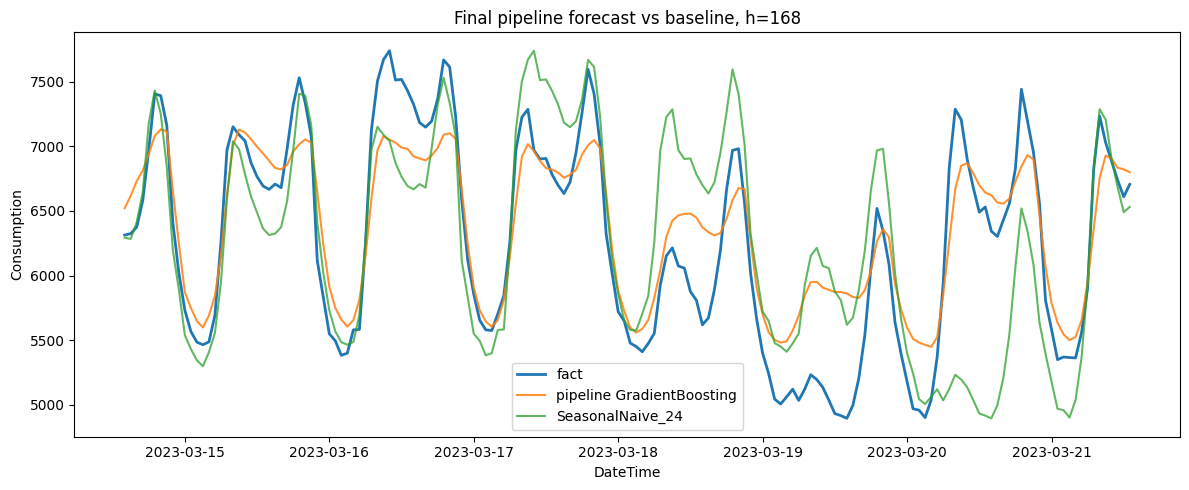

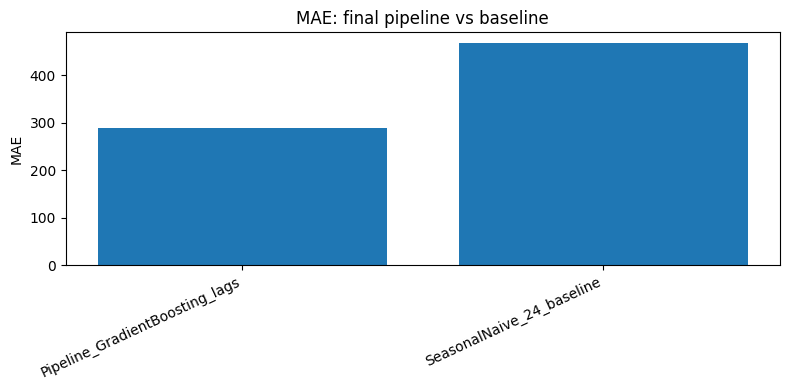

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(forecast_df[DT], forecast_df["y_true"], label="fact", linewidth=2)
plt.plot(forecast_df[DT], forecast_df["pipeline_forecast"], label="pipeline GradientBoosting", alpha=.85)
plt.plot(forecast_df[DT], forecast_df["seasonal_naive_24"], label="SeasonalNaive_24", alpha=.75)
plt.title("Final pipeline forecast vs baseline, h=168")
plt.xlabel("DateTime")
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "task4_pipeline_forecast_h168.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(metrics_df["model"], metrics_df["MAE"])
plt.xticks(rotation=25, ha="right")
plt.title("MAE: final pipeline vs baseline")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig(FIGURES / "task4_pipeline_mae.png", dpi=150)
plt.show()

### Вывод по визуализации результатов

Первый график показывает сравнение фактических значений временного ряда, прогноза итогового пайплайна Pipeline_GradientBoosting_lags и сезонного наивного бейзлайна SeasonalNaive_24 на горизонте 168 часов.
Итоговый пайплайн в целом лучше повторяет форму фактического ряда, чем сезонный бейзлайн: модель учитывает суточные пики и спады, а также менее резко отклоняется от фактических значений на большей части тестового горизонта. При этом на отдельных участках расхождения сохраняются, что согласуется с результатами статистического тестирования остатков.
Сезонный наивный бейзлайн хорошо отражает повторяющуюся суточную структуру, но в отдельные периоды сильнее отклоняется от фактических значений. Это объясняется тем, что бейзлайн использует только значение из аналогичного часа предыдущих суток и не учитывает дополнительные лаговые, скользящие и календарные признаки.

Второй график сравнивает итоговый пайплайн и бейзлайн по метрике MAE. Видно, что MAE у Pipeline_GradientBoosting_lags ниже, чем у SeasonalNaive_24_baseline. Это подтверждает численные результаты из раздела тестирования качества: итоговый пайплайн даёт меньшую среднюю абсолютную ошибку прогноза.

Тем самым, визуализация подтверждает, что выбранный пайплайн на основе GradientBoostingRegressor улучшает качество прогноза относительно сезонного наивного бейзлайна. При этом модель не является идеальной и может дополнительно улучшаться, так как на некоторых временных участках сохраняются отклонения от фактического ряда.

## 9. Итоговые выводы

В рамках задачи №4 был подготовлен итоговый пайплайн решения задачи прогнозирования временного ряда потребления электроэнергии. 
В качестве итоговой модели был выбран GradientBoostingRegressor. Такой выбор основан на результатах задачи №3, где модель градиентного бустинга на лаговых, скользящих и календарных признаках показала лучшее качество среди рассмотренных ML/DL-подходов.

Пайплайн включает следующие основные этапы:

- загрузка подготовленных train/test-выборок;
- формирование признаков временного ряда;
- обучение модели GradientBoostingRegressor;
- рекурсивное прогнозирование на горизонт 168 часов;
- оценка качества прогноза;
- сравнение с сезонным наивным бейзлайном;
- статистическое тестирование остатков и ошибок;
- тестирование производительности;
- сохранение результатов, графиков и отчётных файлов.

Для построения признаков использовались лаги 1, 2, 3, 24, 48 и 168, скользящие средние и стандартные отклонения за 24 и 168 часов, а также календарные признаки. Такой набор признаков выбран с учётом результатов EDA: во временном ряду была выявлена выраженная суточная и недельная сезонность.

На тестовом горизонте 168 часов итоговый пайплайн Pipeline_GradientBoosting_lags показал более высокое качество, чем сезонный наивный бейзлайн SeasonalNaive_24_baseline. MAE итогового пайплайна составила 289.13, RMSE — 362.37, sMAPE — 4.70%, MASE — 0.71. Для сезонного бейзлайна MAE составила 467.57, RMSE — 627.44, sMAPE — 7.60%, MASE — 1.15.
Значение MASE у итогового пайплайна меньше 1, поэтому модель работает лучше сезонного наивного прогноза. Это подтверждает, что использование лаговых, скользящих и календарных признаков вместе с моделью градиентного бустинга улучшает качество прогноза относительно простого сезонного подхода.

Дополнительно было проведено статистическое тестирование пайплайна. Wilcoxon test показал, что абсолютные ошибки итогового пайплайна статистически значимо меньше ошибок сезонного бейзлайна. Это подтверждает преимущество выбранного пайплайна не только по значениям метрик, но и с точки зрения статистической проверки.
При этом t-test среднего остатка показал наличие небольшого систематического смещения прогноза, а Ljung-Box test на лаге 24 выявил сохранение автокорреляции в остатках. Следовательно, итоговый пайплайн улучшает прогноз по сравнению с бейзлайном, но не полностью объясняет сезонную структуру временного ряда. 

Тестирование производительности показало, что пайплайн достаточно быстро обучается и строит прогноз. Обучение модели заняло около 3.61 секунды, а построение рекурсивного прогноза на 168 часов — около 0.18 секунды. 

Таким образом, был подготовлен рабочий пайплайн прогнозирования временного ряда, обоснован выбор его компонентов, проведены тестирование качества, статистическое тестирование и тестирование производительности. Полученные результаты показывают, что итоговый пайплайн на основе GradientBoostingRegressor является более точным, чем сезонный наивный бейзлайн, и может использоваться как итоговое решение задачи прогнозирования потребления электроэнергии.